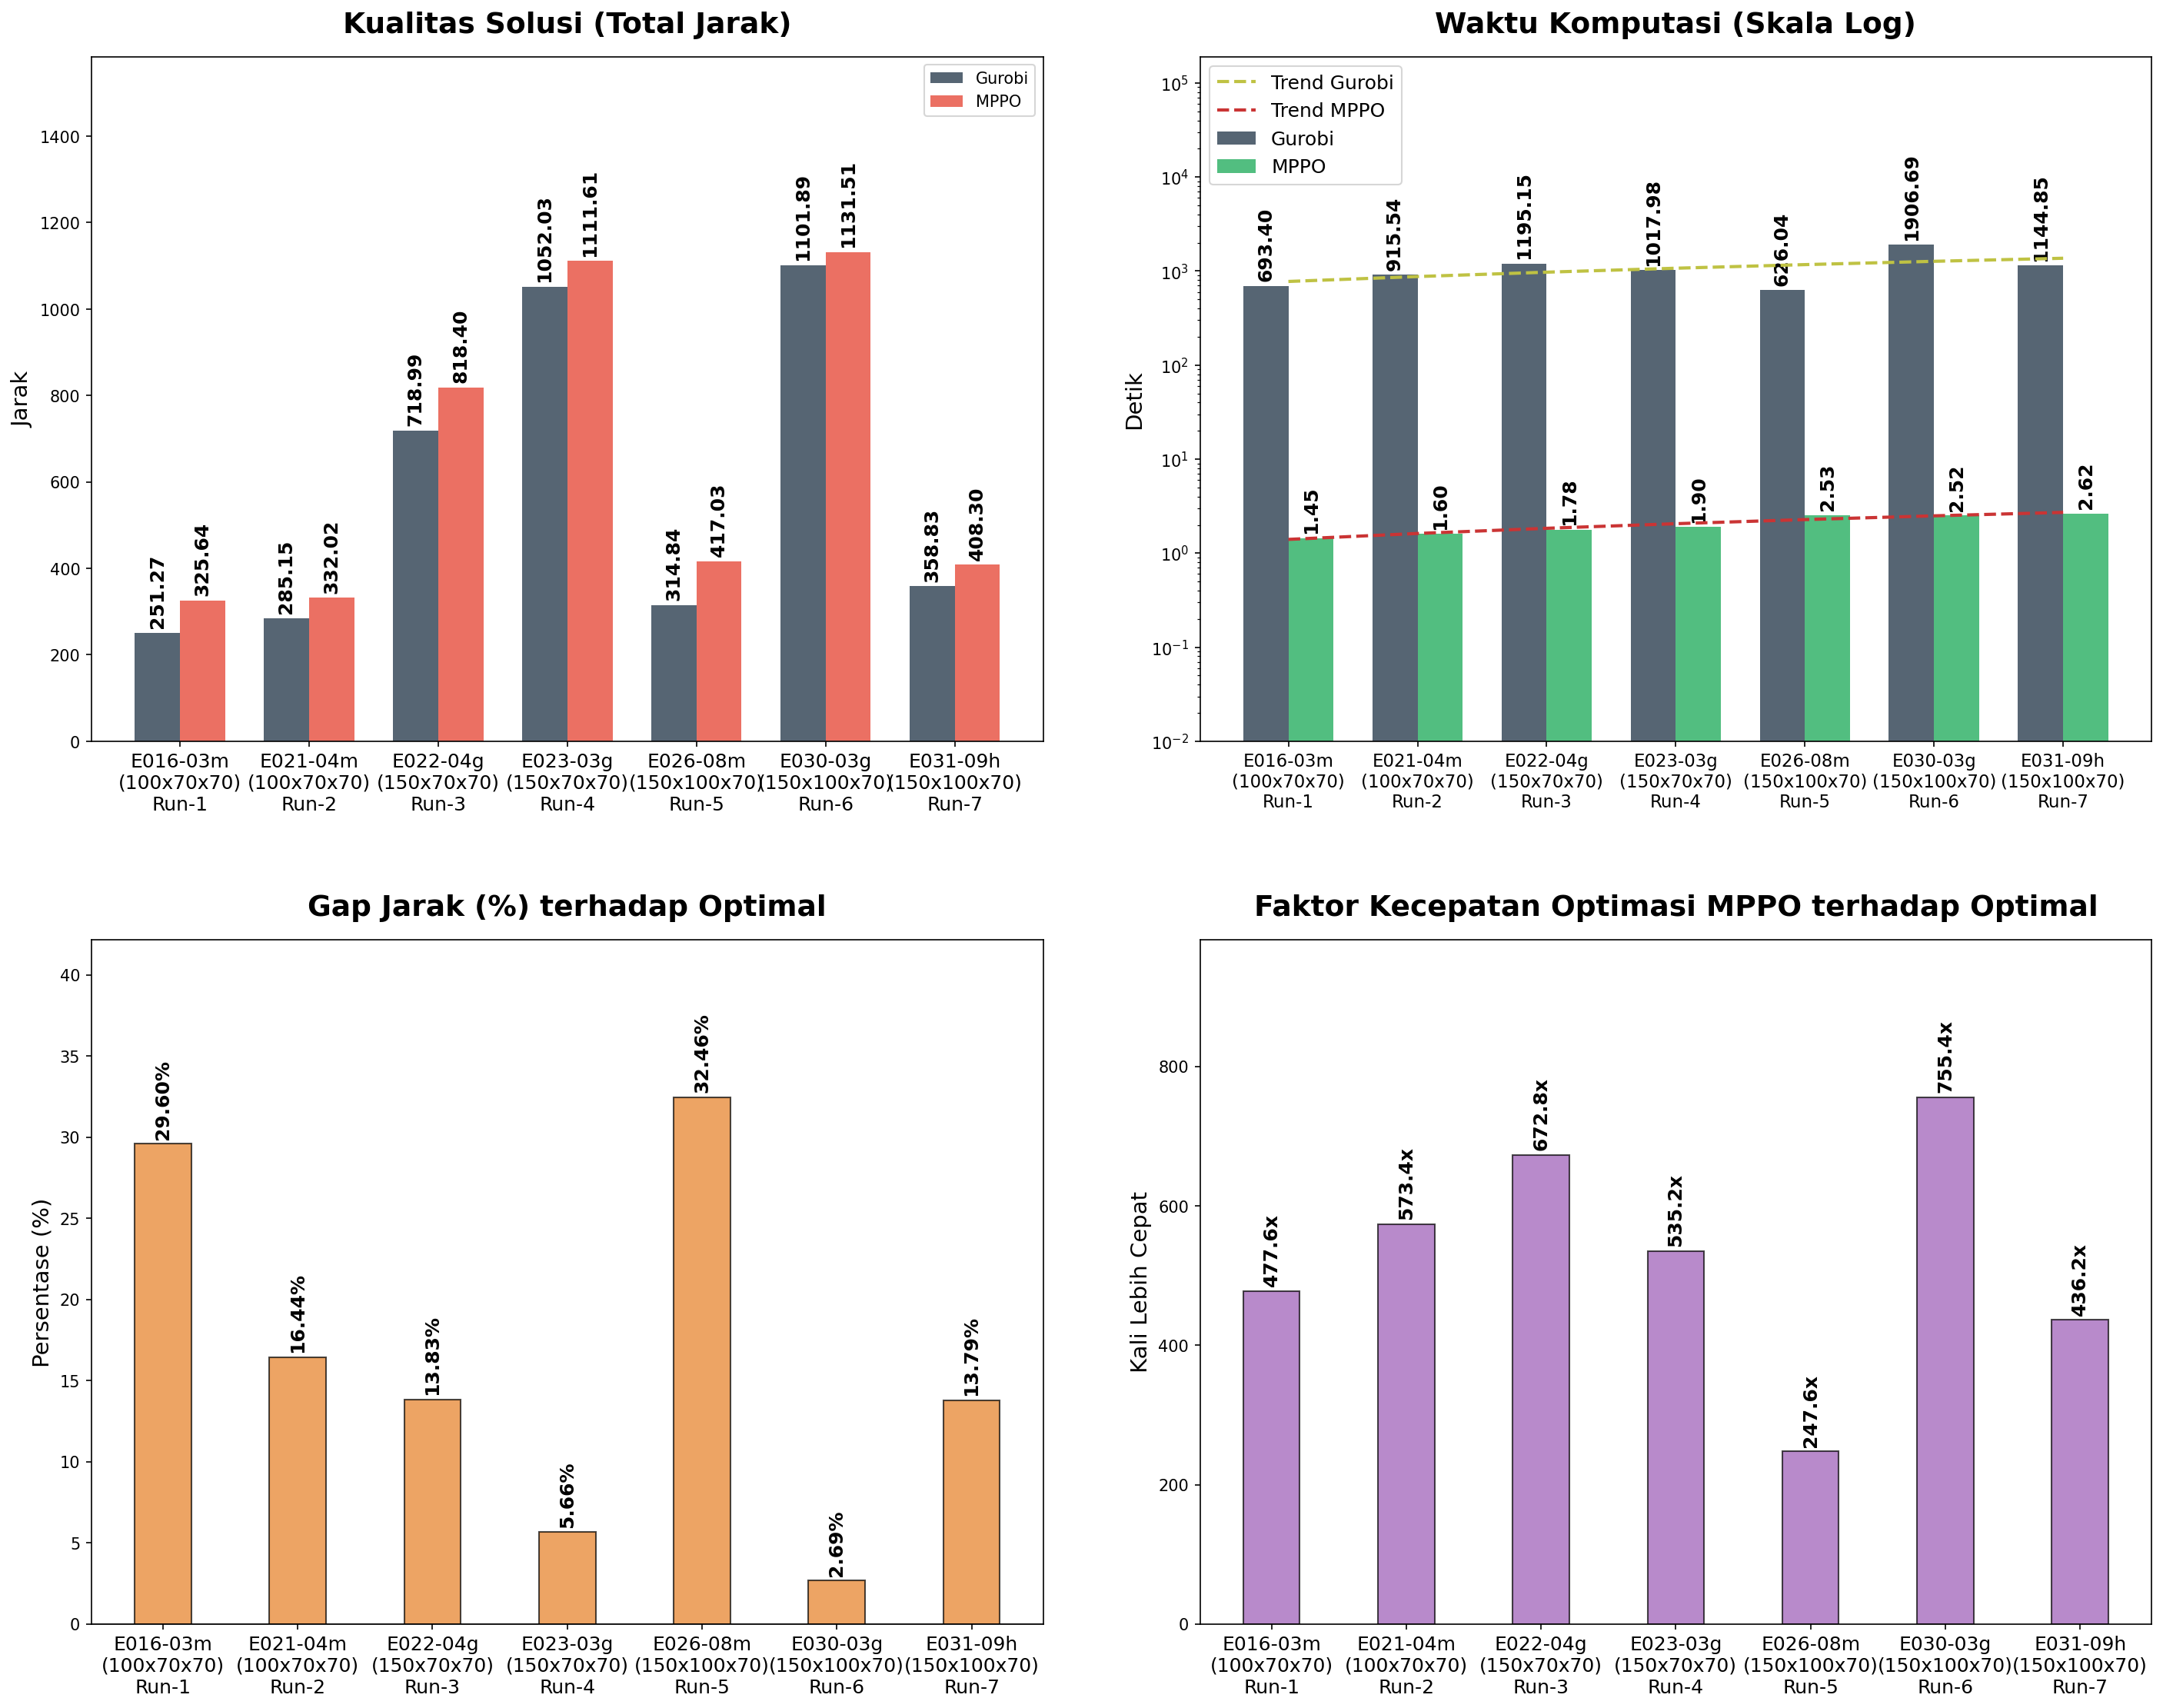

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

def visualize_results(history_file='results.csv'):
    if not os.path.isfile(history_file):
        print(f"File {history_file} tidak ditemukan.")
        return

    df_plot = pd.read_csv(history_file)
    
    datasets = df_plot['dataset_name'].tolist()
    container_sizes = df_plot['container_size'].tolist()
    
    j_gurobi = df_plot['dist_gurobi'].tolist()
    j_drl = df_plot['dist_drl'].tolist()
    
    w_gurobi = [max(0.01, v) for v in df_plot['time_gurobi']]
    w_drl = [max(0.01, v) for v in df_plot['time_drl']]
    
    gap_jarak = [((drl - gur) / gur * 100) if gur != 0 else 0 for drl, gur in zip(j_drl, j_gurobi)]
    speed_up = [(gur / drl) if drl != 0 else 0 for drl, gur in zip(w_drl, w_gurobi)]

    clean_datasets = ["_".join(ds.split('_')[2:]) if ds.count('_') >= 2 else ds for ds in datasets]
    new_labels = [f"{ds}\n({sz})\nRun-{i+1}" for i, (ds, sz) in enumerate(zip(clean_datasets, container_sizes))]

    x = np.arange(len(datasets))
    width = 0.35

    fig, axs = plt.subplots(2, 2, figsize=(20, 16), dpi=150)
    ((ax1, ax2), (ax3, ax4)) = axs

    # --- BARIS 1, KOLOM 1: Kualitas Jarak ---
    r1 = ax1.bar(x - width/2, j_gurobi, width, label='Gurobi', color='#2c3e50', alpha=0.8)
    r2 = ax1.bar(x + width/2, j_drl, width, label='MPPO', color='#e74c3c', alpha=0.8)
    ax1.set_title('Kualitas Solusi (Total Jarak)', fontsize=18, fontweight='bold', pad=15)
    ax1.set_ylabel('Jarak', fontsize=14)
    ax1.set_xticks(x)
    ax1.set_xticklabels(new_labels, fontsize=12)
    ax1.legend()
    ax1.bar_label(r1, padding=3, fmt='%.2f', fontsize=12, rotation=90, fontweight='bold')
    ax1.bar_label(r2, padding=3, fmt='%.2f', fontsize=12, rotation=90, fontweight='bold')
    
    max_j = max(max(j_gurobi), max(j_drl))
    ax1.set_ylim(0, max_j * 1.4)

    # --- BARIS 1, KOLOM 2: Waktu Optimasi ---
    r3 = ax2.bar(x - width/2, w_gurobi, width, label='Gurobi', color='#2c3e50', alpha=0.8)
    r4 = ax2.bar(x + width/2, w_drl, width, label='MPPO', color='#27ae60', alpha=0.8)
    
    if len(datasets) > 1:
        try:
            for data_y, color, lbl in zip([w_gurobi, w_drl], ["#BFC243", "#ca3434"], ["Trend Gurobi", "Trend MPPO"]):
                z = np.polyfit(x, data_y, 1)
                p = np.poly1d(z)
                ax2.plot(x, p(x), color=color, linestyle="--", linewidth=2, label=lbl, zorder=5)
        except:
            pass 

    ax2.set_yscale('log')
    ax2.set_title('Waktu Komputasi (Skala Log)', fontsize=18, fontweight='bold', pad=15)
    ax2.set_ylabel('Detik', fontsize=14)
    ax2.set_xticks(x)
    ax2.set_xticklabels(new_labels, fontsize=11)
    
    ax2.legend(loc='upper left', fontsize=12)
    
    ax2.bar_label(r3, padding=3, fmt='%.2f', fontsize=12, rotation=90, fontweight='bold')
    ax2.bar_label(r4, padding=3, fmt='%.2f', fontsize=12, rotation=90, fontweight='bold')

    max_w = max(max(w_gurobi), max(w_drl))
    ax2.set_ylim(bottom=0.01, top=max_w * 100)

    # --- BARIS 2, KOLOM 1: Gap Jarak (%) ---
    r5 = ax3.bar(x, gap_jarak, width*1.2, color='#e67e22', alpha=0.7, edgecolor='black')
    ax3.set_title('Gap Jarak (%) terhadap Optimal', fontsize=18, fontweight='bold', pad=15)
    ax3.set_ylabel('Persentase (%)', fontsize=14)
    ax3.set_xticks(x)
    ax3.set_xticklabels(new_labels, fontsize=12)
    ax3.axhline(0, color='black', linewidth=0.8)
    ax3.bar_label(r5, padding=3, fmt='%.2f%%', fontsize=12, fontweight='bold', rotation=90)
    ax3.set_ylim(0, max(gap_jarak + [5]) * 1.3)

    # --- BARIS 2, KOLOM 2: Gap Waktu (Speed-up Factor) ---
    r6 = ax4.bar(x, speed_up, width*1.2, color='#9b59b6', alpha=0.7, edgecolor='black')
    ax4.set_title('Faktor Kecepatan Optimasi MPPO terhadap Optimal', fontsize=18, fontweight='bold', pad=15)
    ax4.set_ylabel('Kali Lebih Cepat', fontsize=14)
    ax4.set_xticks(x)
    ax4.set_xticklabels(new_labels, fontsize=12)
    ax4.bar_label(r6, padding=3, fmt='%.1fx', fontsize=12, fontweight='bold', rotation=90)
    ax4.set_ylim(0, max(speed_up + [10]) * 1.3)

    plt.tight_layout(pad=5.0)
    plt.savefig('analisis_komparasi.png')
    plt.show()

visualize_results()